In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# ==========================================
# 1. Data Loading & Preprocessing
# ==========================================

def load_and_process_data(file_path):
    print(f"Loading data from {file_path}...")
    df = pd.read_stata(file_path)

    # Filter Data: Use 2005-2006 for Training, 2007 for Testing
    # We filter early to avoid processing irrelevant years (e.g., 2004)
    df = df[df['year'].isin([2005, 2006, 2007])].copy()
    
    # Handle Missing Values
    # 'ecost_int' (Emissions Cost) has some missing values in 2005. 
    # We use forward fill to maintain time-series continuity.
    df['ecost_int'] = df['ecost_int'].fillna(method='ffill').fillna(method='bfill')

    # Construct Datetime Index
    # 'hour' in the dataset is likely 1-24. We convert to 0-23 for pandas compatibility.
    df['hour_idx'] = df['hour'] - 1 
    df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) + pd.to_timedelta(df['hour_idx'], unit='h')
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)

    # --- Feature Selection ---
    # Target: 
    #   - mg_price: Market Clearing Price (MCP)
    
    # Marginal Costs:
    #   - coal, gas, brent: Marginal input costs (fuel prices)
    #   - ecost_int: Marginal emissions costs (Permit Price * Emissions Rate)
    
    # Demand & Supply Factors:
    #   - rd: Hourly Demand (Residual Demand)
    #   - windx: Wind Speed
    #   - windx2: Wind Speed Squared (Non-linear effect)
    #   - temp: Temperature
    #   - tempx: Maximum Daily Temperature
    
    # Temporal Features (for Seasonality):
    #   - hour, month, weekd (Day of Week)
    
    feature_cols = [
        'coal', 'gas', 'brent', 'ecost_int', 
        'rd', 'windx', 'windx2', 'temp', 'tempx',
        'hour', 'month', 'weekd'
    ]
    target_col = 'mg_price'
    
    return df, feature_cols, target_col

# Load data
file_name = r"Initial code\stata_data\data_regressions_passthrough.dta"
data, feature_cols, target_col = load_and_process_data(file_name)

print(f"Data range: {data.index.min()} to {data.index.max()}")
print(f"Total observations: {len(data)}")

e:\anaconda3\envs\economics_for_challenging_times\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loading data from Initial code\stata_data\data_regressions_passthrough.dta...
Data range: 2005-01-01 00:00:00 to 2007-06-30 23:00:00
Total observations: 21864


C:\Users\Julien\AppData\Local\Temp\ipykernel_30736\1972268659.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ecost_int'] = df['ecost_int'].fillna(method='ffill').fillna(method='bfill')


In [2]:
# ==========================================
# 2. Feature Engineering
# ==========================================

# 2.1 Cyclical Encoding for Time Features
# Encodes hour (0-23) and month (1-12) into sin/cos components to preserve cyclical continuity.
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

# 2.2 One-Hot Encoding for Day of Week
# Capture weekend/weekday effects (weekd is typically 1-7)
dow_dummies = pd.get_dummies(data['weekd'], prefix='dow')
data = pd.concat([data, dow_dummies], axis=1)

# Update feature list to include new engineering features and remove raw categorical ones
processed_features = [
    'coal', 'gas', 'brent', 'ecost_int', 
    'rd', 'windx', 'windx2', 'temp', 'tempx',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
] + list(dow_dummies.columns)

print(f"Final Feature Set ({len(processed_features)} features): {processed_features}")

Final Feature Set (20 features): ['coal', 'gas', 'brent', 'ecost_int', 'rd', 'windx', 'windx2', 'temp', 'tempx', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6', 'dow_7']


In [3]:
# ==========================================
# 3. Train/Test Split & Scaling
# ==========================================

train_df = data[data['year'].isin([2005, 2006])]
test_df = data[data['year'] == 2007]

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# Scaling (MinMax is standard for LSTM inputs to normalize range 0-1)
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit scaler ONLY on training data to avoid data leakage
X_train_scaled = scaler_X.fit_transform(train_df[processed_features])
y_train_scaled = scaler_y.fit_transform(train_df[[target_col]])

X_test_scaled = scaler_X.transform(test_df[processed_features])
y_test_scaled = scaler_y.transform(test_df[[target_col]])

Training samples: 17520
Testing samples: 4344


In [4]:
# ==========================================
# 4. Sequence Generation (Windowing)
# ==========================================

# Window size: 24 hours (Look back at the past 24 hours to predict the next hour)
WINDOW_SIZE = 24

def create_sequences(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, WINDOW_SIZE)

print(f"Input Sequence Shape: {X_train_seq.shape}") # (Samples, TimeSteps, Features)

Input Sequence Shape: (17496, 24, 20)


In [5]:
# ==========================================
# 5. LSTM Model Definition
# ==========================================

model = Sequential()

# Layer 1: LSTM with return_sequences=True
# Captures temporal dependencies over the 24-hour window
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
model.add(Dropout(0.2)) # Regularization

# Layer 2: Second LSTM Layer
model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Output Layer
# Predicts a single continuous value (MCP)
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

e:\anaconda3\envs\economics_for_challenging_times\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,209 (133.63 KB)

 Trainable params: 34,209 (133.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==========================================
# 6. Training
# ==========================================

print("Starting training...")
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,            # You may increase this if loss continues to decrease
    batch_size=32,
    validation_split=0.1, # Use 10% of training data for validation
    shuffle=False,        # Important for time-series: do not shuffle order
    verbose=1
)

Starting training...
Epoch 1/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0182 - val_loss: 0.0133
Epoch 2/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0147 - val_loss: 0.0096
Epoch 3/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0137 - val_loss: 0.0105
Epoch 4/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0127 - val_loss: 0.0116
Epoch 5/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0126 - val_loss: 0.0123
Epoch 6/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0120 - val_loss: 0.0124
Epoch 7/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0116 - val_loss: 0.0120
Epoch 8/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0111 - val_loss: 0.0123
Epoch 9/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0109 - val_loss: 0.0123
Epoch 10/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0107 - val_loss: 0.0126
Epoch 11/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0105 - val_loss: 0.0129
Epoch 12/100
493/493

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Test Results (2007) ---
RMSE: 9.4804
MAE:  7.6839


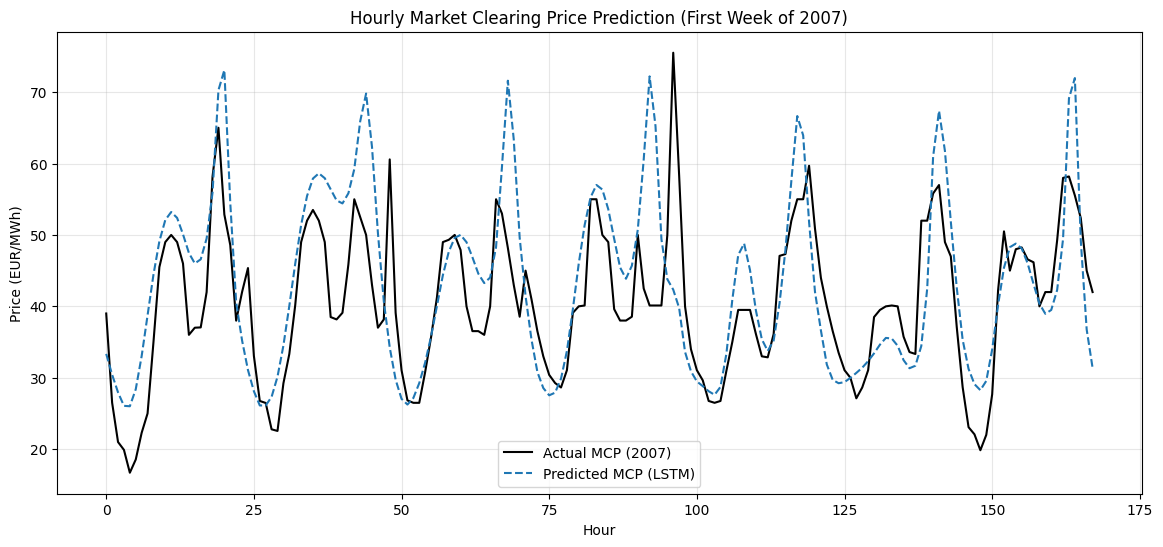

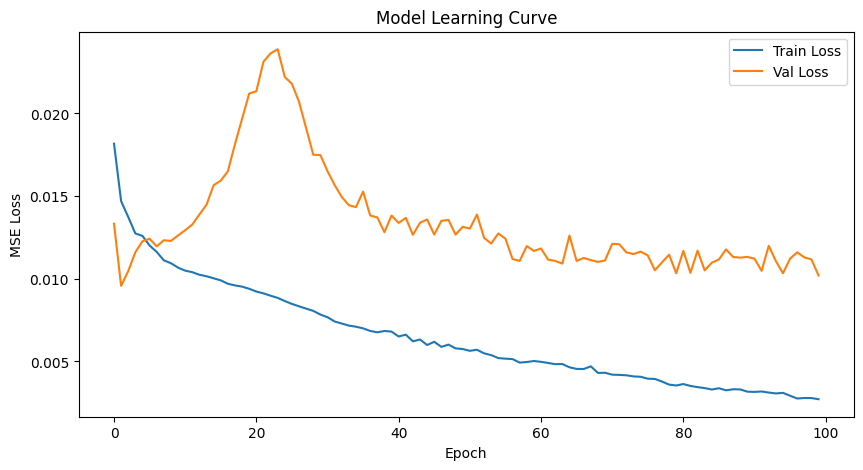

In [7]:
# ==========================================
# 7. Evaluation
# ==========================================

# Predictions
y_pred_scaled = model.predict(X_test_seq)

# Inverse transform to get actual prices in Euros
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test_seq)

# Metrics
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)

print(f"\n--- Test Results (2007) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# Visualization: Plot the first week of 2007
plt.figure(figsize=(14, 6))
plt.plot(y_actual[:168], label='Actual MCP (2007)', color='black')
plt.plot(y_pred[:168], label='Predicted MCP (LSTM)', color='#1f77b4', linestyle='--')
plt.title('Hourly Market Clearing Price Prediction (First Week of 2007)')
plt.xlabel('Hour')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [8]:
# print("Starting training...")
# history = model.fit(
#     X_train_seq, y_train_seq,
#     epochs=20,            # You may increase this if loss continues to decrease
#     batch_size=32,
#     validation_split=0.1, # Use 10% of training data for validation
#     shuffle=False,        # Important for time-series: do not shuffle order
#     verbose=1
# )

# # Predictions
# y_pred_scaled = model.predict(X_test_seq)

# # Inverse transform to get actual prices in Euros
# y_pred = scaler_y.inverse_transform(y_pred_scaled)
# y_actual = scaler_y.inverse_transform(y_test_seq)

# # Metrics
# rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
# mae = mean_absolute_error(y_actual, y_pred)

# print(f"\n--- Test Results (2007) ---")
# print(f"RMSE: {rmse:.4f}")
# print(f"MAE:  {mae:.4f}")

# # Visualization: Plot the first week of 2007
# plt.figure(figsize=(14, 6))
# plt.plot(y_actual[:168], label='Actual MCP (2007)', color='black')
# plt.plot(y_pred[:168], label='Predicted MCP (LSTM)', color='#1f77b4', linestyle='--')
# plt.title('Hourly Market Clearing Price Prediction (First Week of 2007)')
# plt.xlabel('Hour')
# plt.ylabel('Price (EUR/MWh)')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

# # Plot Training Loss
# plt.figure(figsize=(10, 5))
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.title('Model Learning Curve')
# plt.xlabel('Epoch')
# plt.ylabel('MSE Loss')
# plt.legend()
# plt.show()